# Flux Matching vs DSM Comparison

This notebook trains a vector field on a **2D ring distribution** using two objectives:

- **Flux Matching** — learns _any_ distribution generating vector field
- **Denoising Score Matching (DSM)** — learns the score function vector field

The first half shows that both losses are equally easy to use and produce fields that generate the same target distribution. The second half shows using Flux Matching to *optimise additional attributes* of the vector field, a new capability that DSM cannot do.

## 1. Imports & setup

In [98]:
import sys
sys.path.insert(0, '..')

import torch
import random
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

from src.loss import flux_matching_loss

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


## 2. Data

We use a 2D ring as the target distribution because it has rotational symmetry, which will make the curl plots in later sections easy to interpret.

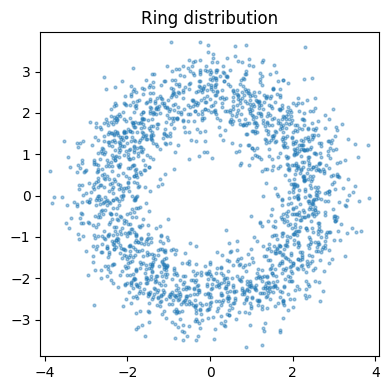

In [99]:
RING_RADIUS = 2.5
RING_WIDTH  = 0.5

def sample_ring(n: int) -> torch.Tensor:
    theta = 2 * torch.pi * torch.rand(n, device=DEVICE)
    r     = RING_RADIUS + RING_WIDTH * torch.randn(n, device=DEVICE)
    return torch.stack([r * torch.cos(theta), r * torch.sin(theta)], dim=-1)

data = sample_ring(2000).cpu()
plt.figure(figsize=(4, 4))
plt.scatter(data[:, 0], data[:, 1], s=4, alpha=0.4)
plt.title('Ring distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 3. The two losses

Both losses share the same interface:

```python
loss_fn(f_theta, x, sigma2)  # → per-sample losses [B]
```

| Argument | Type | Description |
|----------|------|-------------|
| `f_theta` | `nn.Module` | The vector field network. Takes `x` and returns a vector field of the same shape |
| `x` | `Tensor [B, ...]` | Batch of data samples |
| `sigma2` | `scalar Tensor` | Noise variance $\sigma^2$. Controls how much the reference distribution is smoothed |

---

**DSM** trains the network to denoise at a fixed noise level $\sigma$:
$$\mathcal{L}_{\text{DSM}} = \mathbb{E}_{x,\,\epsilon} \left\| f_\theta(x + \sigma\epsilon) + \frac{\epsilon}{\sigma} \right\|^2$$

**Flux matching** trains the network using Eq. 6 from our paper
$$\mathcal L_{\mathrm{flux}}
=
-\mathbb{E}_{\substack{t\sim q,\, x,\,x_t|x}}\!\left[
\frac{1}{q(t)}\,
u_\theta(x_0)^\top
\operatorname{sg}\!\left(
\frac{\partial x_t}{\partial x_0}^{\top}\nabla_{x_t}r_\theta(x_t)
\right)
\right]$$

In [100]:
def dsm_loss(f_theta, x, sigma2):
    sigma = sigma2.sqrt()
    eps   = torch.randn_like(x)
    pred  = f_theta(x + sigma * eps)
    return ((pred + eps / sigma) ** 2).sum(dim=-1)

# flux_matching_loss imported from src.loss — same signature

## 4. Network & training

In [101]:
flux_net = nn.Sequential(
    nn.Linear(2, 128), nn.SiLU(),
    nn.Linear(128, 128), nn.SiLU(),
    nn.Linear(128, 2),
).to(DEVICE)

dsm_net = nn.Sequential(
    nn.Linear(2, 128), nn.SiLU(),
    nn.Linear(128, 128), nn.SiLU(),
    nn.Linear(128, 2),
).to(DEVICE)

SIGMA2 = torch.tensor(0.05, device=DEVICE)
BATCH  = 512
STEPS  = 5000
LR     = 1e-3

def train(net, loss_fn, steps=STEPS):
    opt = torch.optim.Adam(net.parameters(), lr=LR)
    losses = []
    for step in range(steps):
        x    = sample_ring(BATCH)
        loss = loss_fn(net, x, SIGMA2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if (step + 1) % 500 == 0:
            print(f'  step {step+1:4d}  loss={loss.item():.4f}')
    return losses

print('Training flux model...')
flux_losses = train(flux_net, flux_matching_loss)

print('\nTraining DSM model...')
dsm_losses = train(dsm_net, dsm_loss)

print('Training completed.')

Training flux model...
  step  500  loss=24.5845
  step 1000  loss=9.9605
  step 1500  loss=1.8439
  step 2000  loss=40.7095
  step 2500  loss=16.7201
  step 3000  loss=4.4006
  step 3500  loss=234.3497
  step 4000  loss=601.3399
  step 4500  loss=50.4494
  step 5000  loss=193.5680

Training DSM model...
  step  500  loss=37.7568
  step 1000  loss=38.1442
  step 1500  loss=37.3831
  step 2000  loss=38.9032
  step 2500  loss=38.4322
  step 3000  loss=37.7082
  step 3500  loss=37.9630
  step 4000  loss=36.2146
  step 4500  loss=39.7797
  step 5000  loss=38.0925
Training completed.


## 5. Sampling via Langevin dynamics

We can draw samples from either model by running Langevin dynamics using $f_\theta$ as the drift:
$$x_{t+1} = x_t + \frac{\epsilon}{2}\, f_\theta(x_t) + \sqrt{\epsilon}\, \eta, \qquad \eta \sim \mathcal{N}(0, I)$$

Starting from Gaussian noise, both models should converge to the ring distribution.

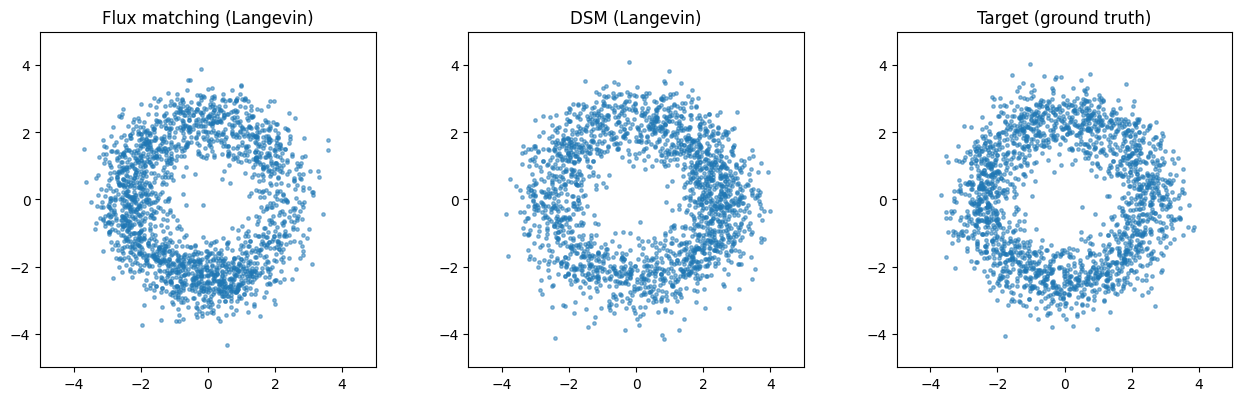

In [102]:
@torch.no_grad()
def langevin_sample(net, n=2000, steps=1000, step_size=1e-1):
    x = torch.randn(n, 2, device=DEVICE)
    for _ in range(steps):
        x = x + 0.5 * step_size * net(x) + (step_size ** 0.5) * torch.randn_like(x)
    return x.cpu()

flux_samples   = langevin_sample(flux_net)
dsm_samples    = langevin_sample(dsm_net)
target_samples = sample_ring(2000).cpu()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, samples, title in zip(axes,
    [flux_samples, dsm_samples, target_samples],
    ['Flux matching (Langevin)', 'DSM (Langevin)', 'Target (ground truth)']):
    ax.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.5)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect('equal'); ax.set_title(title)
plt.tight_layout()
plt.show()

## 6. Learned vector fields

Both models should produce fields that induce the stationary distribution. The arrows are direction normalized. Color encodes magnitude.

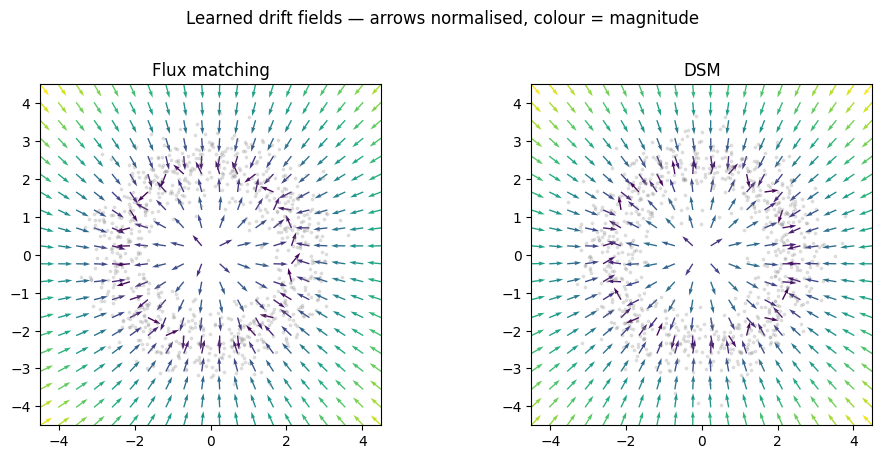

In [103]:
@torch.no_grad()
def plot_field(ax, net, title, lim=4.5, grid=20):
    lin = torch.linspace(-lim, lim, grid)
    gx, gy = torch.meshgrid(lin, lin, indexing='xy')
    pts = torch.stack([gx.flatten(), gy.flatten()], dim=-1).to(DEVICE)

    field = net(pts).cpu().numpy()
    u = field[:, 0].reshape(grid, grid)
    v = field[:, 1].reshape(grid, grid)
    gx, gy = gx.numpy(), gy.numpy()

    mag = np.sqrt(u**2 + v**2) + 1e-8
    ax.quiver(gx, gy, u / mag, v / mag, mag,
              cmap='viridis', scale=grid * 1.2, width=0.004)
    bg = sample_ring(800).cpu()
    ax.scatter(bg[:, 0], bg[:, 1], s=3, alpha=0.2, color='gray')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal'); ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_field(axes[0], flux_net, 'Flux matching')
plot_field(axes[1], dsm_net,  'DSM')
plt.suptitle('Learned drift fields — arrows normalised, colour = magnitude', y=1.01)
plt.tight_layout()
plt.show()

## 7. Curl fields

The scalar curl of a 2D field $f = (f_x, f_y)$ is:
$$\text{curl}\, f = \frac{\partial f_y}{\partial x} - \frac{\partial f_x}{\partial y}$$

A **gradient field** (like the score function) always has zero curl. DSM explicitly minimises $\|f_\theta - \nabla \log p\|^2$, so it is strongly pulled toward a zero-curl solution.

Flux Matching only constrains the *divergence* of the flux, leaving any curl dynamics free to exist. As a result, the learned field can pickup curl.

/tmp/ipykernel_140878/2872457075.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


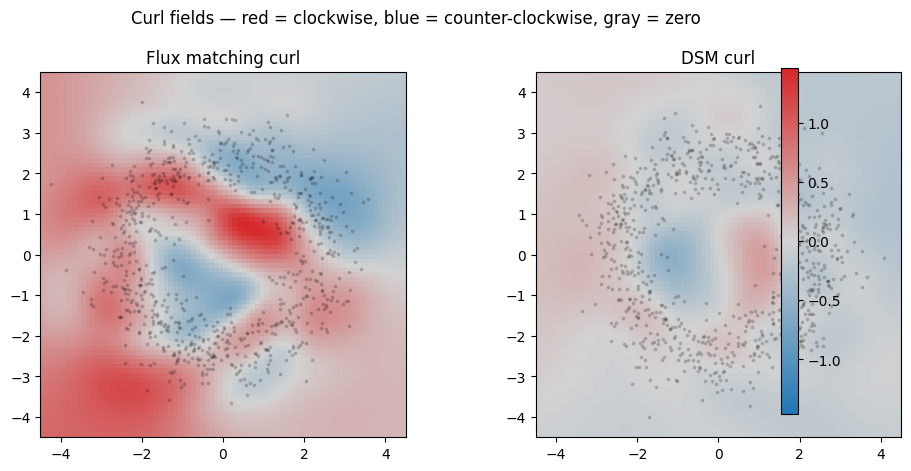

Flux matching  mean|curl| = 0.4066
DSM            mean|curl| = 0.1198


In [104]:
def curl_2d(f_theta, x):
    with torch.enable_grad():
        x = x.detach().requires_grad_(True)
        f = f_theta(x)
        grad_fx = torch.autograd.grad(f[:, 0].sum(), x, retain_graph=True)[0]
        grad_fy = torch.autograd.grad(f[:, 1].sum(), x)[0]
    return (grad_fy[:, 0] - grad_fx[:, 1]).detach()

curl_cmap = LinearSegmentedColormap.from_list('curl', ['tab:blue', 'lightgray', 'tab:red'])

def plot_curl_field(ax, net, title, norm, lim=4.5, grid=80):
    lin = torch.linspace(-lim, lim, grid, device=DEVICE)
    gx, gy = torch.meshgrid(lin, lin, indexing='xy')
    pts = torch.stack([gx.flatten(), gy.flatten()], dim=-1)
    curl = curl_2d(net, pts).cpu().numpy().reshape(grid, grid)

    ax.imshow(curl, extent=[-lim, lim, -lim, lim], origin='lower',
              aspect='equal', cmap=curl_cmap, norm=norm)
    bg = sample_ring(800).cpu()
    ax.scatter(bg[:, 0], bg[:, 1], s=3, alpha=0.15, color='black')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_title(title)
    return curl

LIM, GRID = 4.5, 80
# compute on a throwaway grid just to set the shared colour scale
lin = torch.linspace(-LIM, LIM, GRID, device=DEVICE)
gx, gy = torch.meshgrid(lin, lin, indexing='xy')
pts = torch.stack([gx.flatten(), gy.flatten()], dim=-1)
flux_curl_vals = curl_2d(flux_net, pts).cpu().numpy()
dsm_curl_vals  = curl_2d(dsm_net,  pts).cpu().numpy()
abs_max = max(np.abs(flux_curl_vals).max(), np.abs(dsm_curl_vals).max(), 1e-8)
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0.0, vmax=abs_max)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
flux_curl_grid = plot_curl_field(axes[0], flux_net, 'Flux matching curl', norm)
dsm_curl_grid  = plot_curl_field(axes[1], dsm_net,  'DSM curl', norm)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=curl_cmap),
             ax=axes, fraction=0.046, pad=0.04)
plt.suptitle('Curl fields — red = clockwise, blue = counter-clockwise, gray = zero', y=1.01)
plt.tight_layout()
plt.show()

print(f'Flux matching  mean|curl| = {np.abs(flux_curl_grid).mean():.4f}')
print(f'DSM            mean|curl| = {np.abs(dsm_curl_grid).mean():.4f}')

## 8. Optimising Additional Vector Field Attributes (New Capability Enabled by Flux Matching)

Because Flux Matching does not pin the vector field to be the score, we can **optimise the vector field explicitly**. Here we inject a spiral by adding a penalty that rewards tangential flow (i.e. we want $f_\theta(x)$ to have a large component in the direction $\hat{t}(x) = [-y, x]^\top / \|x\|$).

$$\mathcal{L}_{\text{spiral}} = -\mathbb{E}_x \left[ f_\theta(x) \cdot \hat{t}(x) \right]$$

The total loss is $\mathcal{L}_{\text{flux}} + \lambda_{\text{spiral}} \cdot \mathcal{L}_{\text{spiral}}$. The Flux Matching term keeps the field generating the correct distribution; the spiral term shapes *how* it gets there.

**This is fundamentally impossible with DSM.** DSM minimises $\mathbb{E}[\|f_\theta - \nabla \log p\|^2]$, which has the score function as its unique minimizer. Any spiral penalty would conflict directly against the score matching objective, and the two cannot be jointly satisfied unlike Flux Matching.

In [105]:
def spiral_penalty(f_theta, x):
    r = x.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    tangent = torch.stack([-x[:, 1], x[:, 0]], dim=-1) / r  # unit tangent
    f = f_theta(x)
    return -(f * tangent).sum(dim=-1)  # negative = we want to maximise alignment

SPIRAL_LAMBDA = 5.0

def flux_spiral_loss(f_theta, x, sigma2):
    return flux_matching_loss(f_theta, x, sigma2) + SPIRAL_LAMBDA * spiral_penalty(f_theta, x)

spiral_net = make_mlp(2).to(DEVICE)

print('Training Flux + spiral model...')
spiral_losses = train(spiral_net, flux_spiral_loss)
print('Finished Flux + spiral model')

Training Flux + spiral model...
  step  500  loss=18.9090
  step 1000  loss=80.9596
  step 1500  loss=-6.7082
  step 2000  loss=34.8104
  step 2500  loss=396.2479
  step 3000  loss=425.6208
  step 3500  loss=187.0262
  step 4000  loss=26.4357
  step 4500  loss=457.6281
  step 5000  loss=-5.0513
Finished Flux + spiral model


### Sampling from the spiral model

Despite the added spiral penalty, the model should still recover the ring. The penalty only shapes the vector filed, not the stationary distribution.

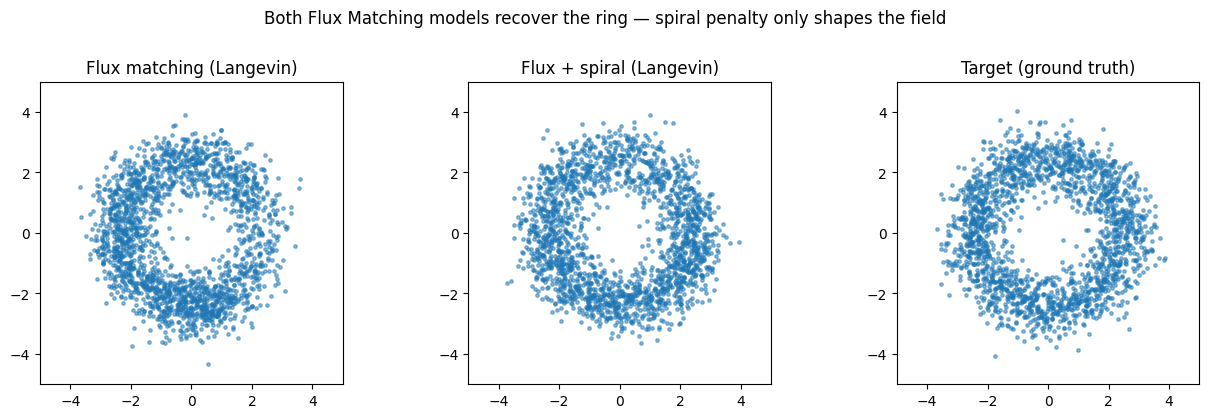

In [108]:
spiral_samples = langevin_sample(spiral_net)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, samples, title in zip(axes,
    [flux_samples, spiral_samples, target_samples],
    ['Flux matching (Langevin)', 'Flux + spiral (Langevin)', 'Target (ground truth)']):
    ax.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.5)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect('equal'); ax.set_title(title)
plt.suptitle('Both Flux Matching models recover the ring — spiral penalty only shapes the field', y=1.02)
plt.tight_layout()
plt.show()

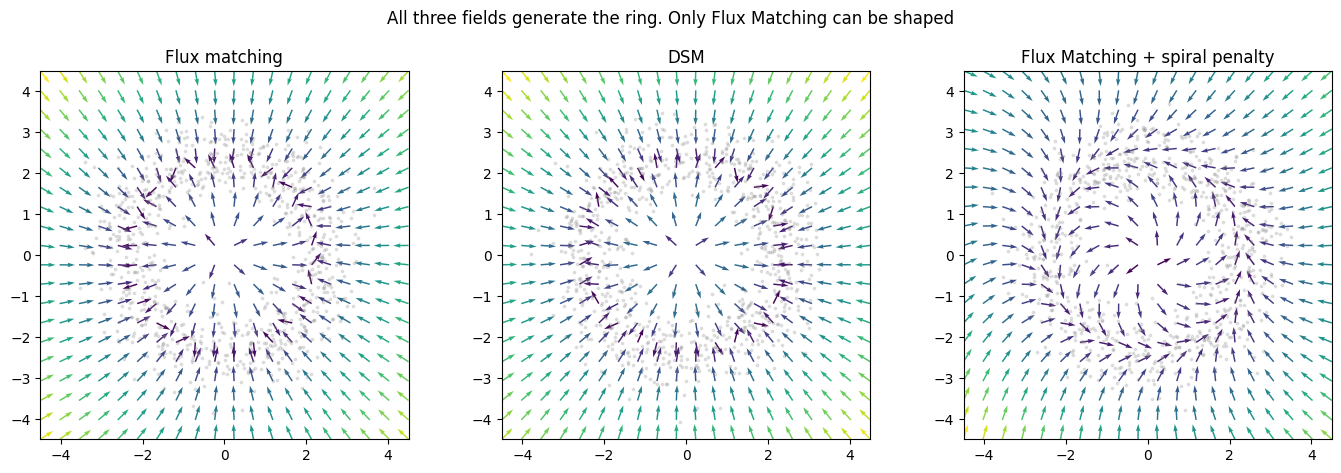

/tmp/ipykernel_140878/651782566.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


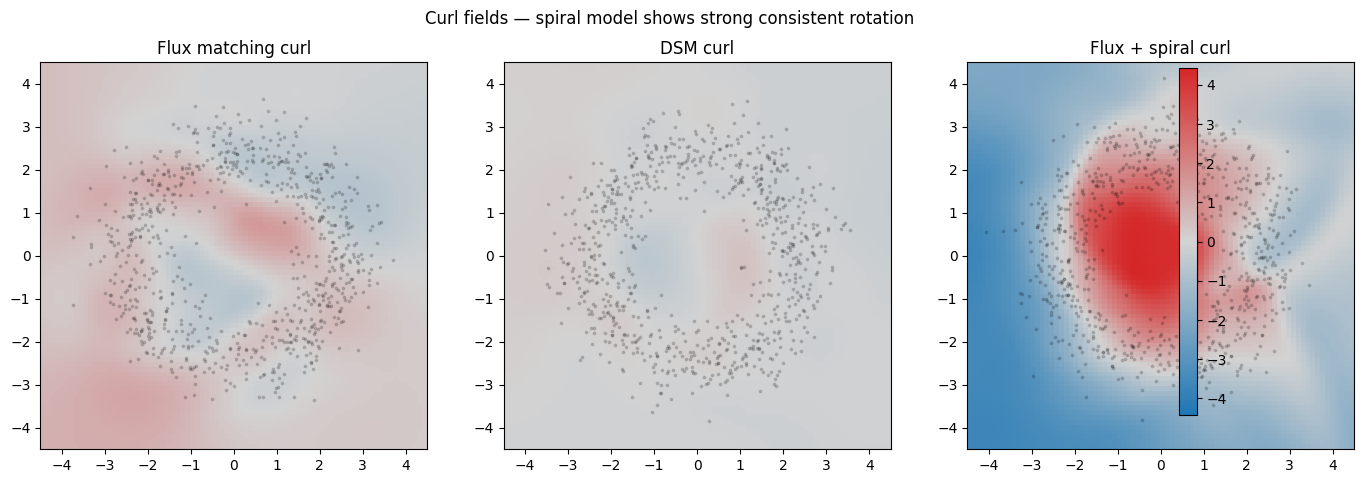

Flux matching  mean|curl| = 0.4066
DSM            mean|curl| = 0.1198
Flux + spiral  mean|curl| = 1.6441


In [109]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
plot_field(axes[0], flux_net,   'Flux matching')
plot_field(axes[1], dsm_net,    'DSM')
plot_field(axes[2], spiral_net, 'Flux Matching + spiral penalty')
plt.suptitle('All three fields generate the ring. Only Flux Matching can be shaped', y=1.01)
plt.tight_layout()
plt.show()

# curl comparison across all three
pts_cpu = torch.stack([
    *torch.meshgrid(
        torch.linspace(-LIM, LIM, GRID, device=DEVICE),
        torch.linspace(-LIM, LIM, GRID, device=DEVICE),
        indexing='xy'
    )
], dim=-1).reshape(-1, 2)

spiral_curl_vals = curl_2d(spiral_net, pts_cpu).cpu().numpy()
abs_max3 = max(np.abs(flux_curl_vals).max(),
               np.abs(dsm_curl_vals).max(),
               np.abs(spiral_curl_vals).max(), 1e-8)
norm3 = TwoSlopeNorm(vmin=-abs_max3, vcenter=0.0, vmax=abs_max3)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
plot_curl_field(axes[0], flux_net,   'Flux matching curl', norm3)
plot_curl_field(axes[1], dsm_net,    'DSM curl',           norm3)
im = axes[2].imshow(
    spiral_curl_vals.reshape(GRID, GRID),
    extent=[-LIM, LIM, -LIM, LIM], origin='lower',
    aspect='equal', cmap=curl_cmap, norm=norm3)
bg = sample_ring(800).cpu()
axes[2].scatter(bg[:, 0], bg[:, 1], s=3, alpha=0.15, color='black')
axes[2].set_title('Flux + spiral curl')
fig.colorbar(plt.cm.ScalarMappable(norm=norm3, cmap=curl_cmap),
             ax=axes, fraction=0.046, pad=0.04)
plt.suptitle('Curl fields — spiral model shows strong consistent rotation', y=1.01)
plt.tight_layout()
plt.show()

print(f'Flux matching  mean|curl| = {np.abs(flux_curl_vals).mean():.4f}')
print(f'DSM            mean|curl| = {np.abs(dsm_curl_vals).mean():.4f}')
print(f'Flux + spiral  mean|curl| = {np.abs(spiral_curl_vals).mean():.4f}')